In [49]:
from deepspeed.profiling.flops_profiler import get_model_profile
import torch
from sympy.printing.pretty.pretty_symbology import line_width
from torch import nn

def profile(model: torch.nn.Module, input_shape: tuple[int, ...]):
    flops, macs, params = get_model_profile(model, input_shape, warm_up=10, print_profile=True, as_string=False)
    return flops

In [50]:
def flops_linear(input_dim, output_dim, bias=True):
    """
    Calculate the number of FLOPs for a linear layer.
    """
    flops = (input_dim + input_dim - 1) * output_dim # multiplication and accumulation for each output
    if bias:
        flops += output_dim
    return flops

in_dim = out_dim = 128
bias = True

ds_flops = profile(nn.Linear(in_dim, out_dim, bias=bias), (1, in_dim))
my_flops = flops_linear(in_dim, out_dim, bias)
print(f"Deepspeed FLOPs: {ds_flops}")
print(f"My FLOPs: {my_flops}")

[2025-10-17 10:22:58,780] [INFO] [profiler.py:1254:get_model_profile] Flops profiler warming-up...
[2025-10-17 10:22:58,782] [INFO] [profiler.py:82:start_profile] Flops profiler started

-------------------------- DeepSpeed Flops Profiler --------------------------
Profile Summary at step 10:
Notations:
data parallel size (dp_size), model parallel size(mp_size),
number of parameters (params), number of multiply-accumulate operations(MACs),
number of floating-point operations (flops), floating-point operations per second (FLOPS),
fwd latency (forward propagation latency), bwd latency (backward propagation latency),
step (weights update latency), iter latency (sum of fwd, bwd and step latency)

params per GPU:                                                         16.51 K 
params of model = params per GPU * mp_size:                             0       
fwd MACs per GPU:                                                       16.38 KMACs
fwd flops per GPU:                                  

In [51]:
def flops_mm(a_size, b_size):
    """
    Calculate the number of FLOPs for matrix multiplication.
    """
    assert a_size[1] == b_size[0], "Incompatible matrix sizes for multiplication"
    n, p = a_size
    _, m = b_size
    flops = n * (2 * p - 1) * m  # multiplication and accumulation for each output
    return flops


class MatrixMultiply(nn.Module):
    def forward(self, a, b):
        return torch.bmm(a, b)


a_size = (5, 3)
b_size = (3, 4)
ds_flops = \
get_model_profile(MatrixMultiply(), args=[torch.randn(*a_size), torch.randn(*b_size)], warm_up=10, print_profile=True,
                  as_string=False)[0]
my_flops = flops_mm(a_size, b_size)
print(f"Deepspeed FLOPs: {ds_flops}")
print(f"My FLOPs: {my_flops}")

[2025-10-17 10:22:58,834] [INFO] [profiler.py:1254:get_model_profile] Flops profiler warming-up...
[2025-10-17 10:22:58,835] [INFO] [profiler.py:82:start_profile] Flops profiler started

-------------------------- DeepSpeed Flops Profiler --------------------------
Profile Summary at step 10:
Notations:
data parallel size (dp_size), model parallel size(mp_size),
number of parameters (params), number of multiply-accumulate operations(MACs),
number of floating-point operations (flops), floating-point operations per second (FLOPS),
fwd latency (forward propagation latency), bwd latency (backward propagation latency),
step (weights update latency), iter latency (sum of fwd, bwd and step latency)

params per GPU:                                                         0       
params of model = params per GPU * mp_size:                             0       
fwd MACs per GPU:                                                       60 MACs 
fwd flops per GPU:                                     

In [52]:
def flops_conv2d(input_channels, output_channels, kernel_size, input_height, input_width, bias=True):
    """
    Calculate the number of FLOPs for a 2D convolution layer.
    """
    flops = output_channels * (input_channels * 2 * (kernel_size ** 2) - 1) * input_height * input_width
    if bias:
        flops += output_channels
    return flops


input_channels = 3
output_channels = 16
kernel_size = 3
input_height = input_width = 64
bias = True

ds_flops = profile(nn.Conv2d(input_channels, output_channels, kernel_size, bias=bias),
                   (1, input_channels, input_height, input_width))
my_flops = flops_conv2d(input_channels, output_channels, kernel_size, input_height, input_width, bias)
print(f"Deepspeed FLOPs: {ds_flops}")
print(f"My FLOPs: {my_flops}")

[2025-10-17 10:22:58,903] [INFO] [profiler.py:1254:get_model_profile] Flops profiler warming-up...
[2025-10-17 10:22:58,965] [INFO] [profiler.py:82:start_profile] Flops profiler started

-------------------------- DeepSpeed Flops Profiler --------------------------
Profile Summary at step 10:
Notations:
data parallel size (dp_size), model parallel size(mp_size),
number of parameters (params), number of multiply-accumulate operations(MACs),
number of floating-point operations (flops), floating-point operations per second (FLOPS),
fwd latency (forward propagation latency), bwd latency (backward propagation latency),
step (weights update latency), iter latency (sum of fwd, bwd and step latency)

params per GPU:                                                         448     
params of model = params per GPU * mp_size:                             0       
fwd MACs per GPU:                                                       1.66 MMACs
fwd flops per GPU:                                   

In [53]:
def flops_grouped_conv_2d(input_channels, output_channels, kernel_size, input_height, input_width, bias=True):
    """
    Calculate the number of FLOPs for a 2D grouped conv layer.
    """
    assert input_channels == output_channels
    flops = output_channels * (2 * (kernel_size ** 2) - 1) * input_height * input_width
    if bias:
        flops += output_channels
    return flops


input_channels = 16
output_channels = 16
kernel_size = 3
input_height = input_width = 64
bias = True

ds_flops = profile(nn.Conv2d(input_channels, output_channels, kernel_size, bias=bias, groups=output_channels),
                   (1, input_channels, input_height, input_width))
my_flops = flops_grouped_conv_2d(input_channels, output_channels, kernel_size, input_height, input_width, bias)
print(f"Deepspeed FLOPs: {ds_flops}")
print(f"My FLOPs: {my_flops}")

[2025-10-17 10:22:58,990] [INFO] [profiler.py:1254:get_model_profile] Flops profiler warming-up...
[2025-10-17 10:22:58,994] [INFO] [profiler.py:82:start_profile] Flops profiler started

-------------------------- DeepSpeed Flops Profiler --------------------------
Profile Summary at step 10:
Notations:
data parallel size (dp_size), model parallel size(mp_size),
number of parameters (params), number of multiply-accumulate operations(MACs),
number of floating-point operations (flops), floating-point operations per second (FLOPS),
fwd latency (forward propagation latency), bwd latency (backward propagation latency),
step (weights update latency), iter latency (sum of fwd, bwd and step latency)

params per GPU:                                                         160     
params of model = params per GPU * mp_size:                             0       
fwd MACs per GPU:                                                       553.54 KMACs
fwd flops per GPU:                                 

In [54]:
def flops_pooling2d(input_channels, kernel_size, input_height, input_width, stride=1, padding=0, mode="avg"):
    """
    Calculate FLOPs for 2D pooling (MaxPool2d or AvgPool2d).

    Args:
        input_channels (int): number of channels
        kernel_size (int): pooling kernel size (square assumed)
        input_height (int): input feature map height
        input_width (int): input feature map width
        stride (int): pooling stride
        padding (int): pooling padding
        mode (str): "max" or "avg"
    """
    # Output spatial size after pooling
    output_height = (input_height + 2 * padding - kernel_size) // stride + 1
    output_width = (input_width + 2 * padding - kernel_size) // stride + 1

    if mode == "max":
        flops_per_element = kernel_size ** 2 - 1
    elif mode == "avg":
        flops_per_element = kernel_size ** 2  # adds + divide
    else:
        raise ValueError("mode must be 'max' or 'avg'")

    total_flops = input_channels * output_height * output_width * flops_per_element
    return total_flops



input_channels = 1
output_channels = 16
kernel_size = 3
input_height = input_width = 64

ds_flops = profile(nn.AvgPool2d(kernel_size=kernel_size,stride=1), (1, input_channels, input_height, input_width))
my_flops = flops_pooling2d(input_channels, kernel_size, input_height, input_width,)
print(f"Deepspeed FLOPs: {ds_flops}")
print(f"My FLOPs: {my_flops}")

[2025-10-17 10:22:59,034] [INFO] [profiler.py:1254:get_model_profile] Flops profiler warming-up...
[2025-10-17 10:22:59,042] [INFO] [profiler.py:82:start_profile] Flops profiler started

-------------------------- DeepSpeed Flops Profiler --------------------------
Profile Summary at step 10:
Notations:
data parallel size (dp_size), model parallel size(mp_size),
number of parameters (params), number of multiply-accumulate operations(MACs),
number of floating-point operations (flops), floating-point operations per second (FLOPS),
fwd latency (forward propagation latency), bwd latency (backward propagation latency),
step (weights update latency), iter latency (sum of fwd, bwd and step latency)

params per GPU:                                                         0       
params of model = params per GPU * mp_size:                             0       
fwd MACs per GPU:                                                       0 MACs  
fwd flops per GPU:                                     

In [55]:
def flops_self_attention(seq_length, embed_dim, ff_factor=4):
    """
    Calculate the number of FLOPs for a self-attention layer.
    """
    flops = 0
    # Self-attention
    # Query, Key, Value projections
    flops += seq_length * flops_linear(embed_dim, embed_dim) * 3  # Q, K, V projections
    # Attention scores
    flops += flops_mm([seq_length, embed_dim], [embed_dim, seq_length])  # QK^T
    # Scaling
    flops += seq_length
    # Softmax over rows
    flops += seq_length ** 2 # should be seq_length * (3 * seq_length - 1) due to Softmax (exp, sum, division) but seems to be optimized into one op
    # Y projection
    flops += flops_mm([seq_length, seq_length], [seq_length, embed_dim])
    # head unify
    flops += seq_length * flops_linear(embed_dim, embed_dim)

    return flops


seq_length = 128
embed_dim = 64
ff_factor = 4


class Wrapper(nn.Module):
    def __init__(self, embed_dim, ff_factor):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(embed_dim, num_heads=1)
        self.linear1 = nn.Linear(embed_dim, embed_dim * ff_factor)
        self.linear2 = nn.Linear(embed_dim * ff_factor, embed_dim)

    def forward(self, x):
        attn_output, _ = self.self_attn(x, x, x)
        x = self.linear1(attn_output)
        x = self.linear2(x)
        return x


ds_flops = get_model_profile(Wrapper(embed_dim, ff_factor), (1, seq_length, embed_dim), warm_up=10, print_profile=True,
                             as_string=False)[0]
my_flops = flops_self_attention(seq_length, embed_dim)
print(f"Deepspeed FLOPs: {ds_flops}")
print(f"My FLOPs: {my_flops}")

[2025-10-17 10:22:59,126] [INFO] [profiler.py:1254:get_model_profile] Flops profiler warming-up...
[2025-10-17 10:22:59,175] [INFO] [profiler.py:82:start_profile] Flops profiler started

-------------------------- DeepSpeed Flops Profiler --------------------------
Profile Summary at step 10:
Notations:
data parallel size (dp_size), model parallel size(mp_size),
number of parameters (params), number of multiply-accumulate operations(MACs),
number of floating-point operations (flops), floating-point operations per second (FLOPS),
fwd latency (forward propagation latency), bwd latency (backward propagation latency),
step (weights update latency), iter latency (sum of fwd, bwd and step latency)

params per GPU:                                                         49.73 K 
params of model = params per GPU * mp_size:                             0       
fwd MACs per GPU:                                                       6.31 MMACs
fwd flops per GPU:                                   

In [56]:
def flops_local_self_attention(seq_length, embed_dim, kernel_size, ff_factor=4):
    """
    Calculate the number of FLOPs for a self-attention layer.
    """
    flops = 0
    # Self-attention
    # Query, Key, Value projections
    flops += seq_length * flops_linear(embed_dim, embed_dim) * 3  # Q, K, V projections
    # Attention scores (local)
    flops += flops_mm([seq_length, embed_dim], [embed_dim, kernel_size ** 2])
    # Scaling
    flops += seq_length
    # Softmax over rows
    flops += seq_length * kernel_size ** 2
    # Y projection
    flops += flops_mm([seq_length, seq_length], [seq_length, embed_dim])
    # head unify
    flops += seq_length * flops_linear(embed_dim, embed_dim)

    return flops

seq_length = 4096
embed_dim = 64
kernel_size = 3
ff_factor = 4

print(flops_self_attention(seq_length, embed_dim, ff_factor))
print(flops_local_self_attention(seq_length, embed_dim, kernel_size, ff_factor))

4428926976
2286161920


In [57]:
import pandas as pd

results_df = pd.DataFrame(columns=['operation', 'kernel', 'spatial', 'flops'])
done_4_full_atn = False
for kernel_size in [3, 5, 7, 9]:
    for config in [(64, 192), (128, 69), (320, 48), (512, 24)]:
        n_channel, spatial_dim = config
        kernel_label = f'{kernel_size}²'
        spatial_label = f'{n_channel}x{spatial_dim}²'

        pool_flops = flops_pooling2d(n_channel, kernel_size, input_height, input_width)
        results_df.loc[len(results_df)] = ['pooling', kernel_label, spatial_label, pool_flops]

        group_conv_flops = flops_grouped_conv_2d(n_channel, n_channel, kernel_size, input_height, input_width)
        results_df.loc[len(results_df)] = ['grouped conv', kernel_label, spatial_label, group_conv_flops]

        conv_flops = flops_conv2d(n_channel, n_channel, kernel_size, spatial_dim, spatial_dim)
        results_df.loc[len(results_df.index)] = ['conv', kernel_label, spatial_label, conv_flops]

        local_attn_flops = flops_local_self_attention(spatial_dim**2, n_channel, kernel_size)
        results_df.loc[len(results_df.index)] = ['local attn', kernel_label, spatial_label, local_attn_flops]

        #if not done_4_full_atn:
        full_atn_flops = flops_self_attention(spatial_dim**2, n_channel)
        results_df.loc[len(results_df.index)] = ['global attn', kernel_label, spatial_label, full_atn_flops]
    done_4_full_atn = True

print(results_df)

       operation kernel  spatial         flops
0        pooling     3²  64x192²       2214144
1   grouped conv     3²  64x192²       4456512
2           conv     3²  64x192²    2715549760
3     local attn     3²  64x192²  175194279936
4    global attn     3²  64x192²  349097988096
..           ...    ...      ...           ...
75       pooling     9²  512x24²     130056192
76  grouped conv     9²  512x24²     337641984
77          conv     9²  512x24²   24460886528
78    local attn     9²  512x24²    1595179584
79   global attn     9²  512x24²    1887142464

[80 rows x 4 columns]


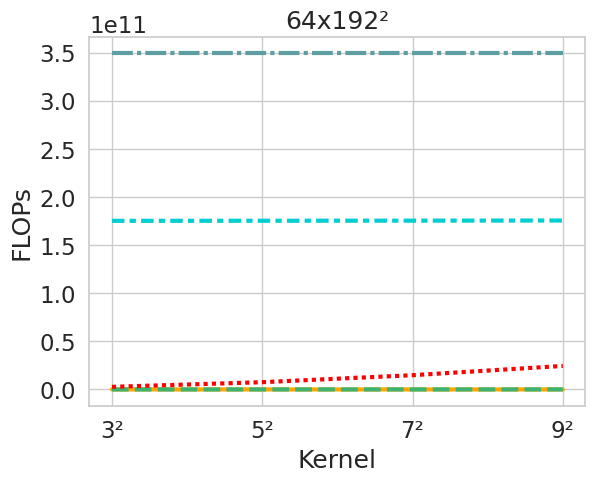

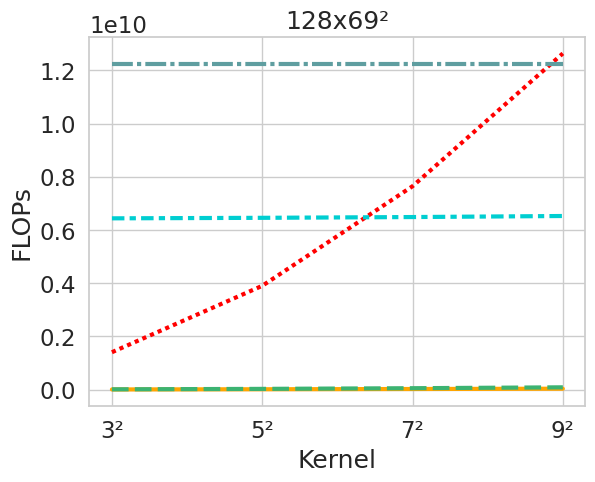

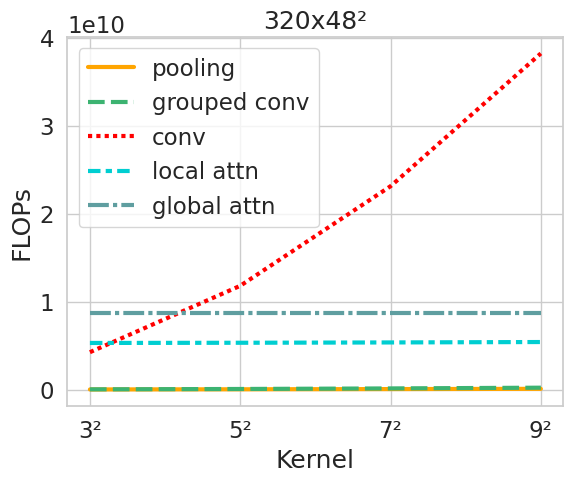

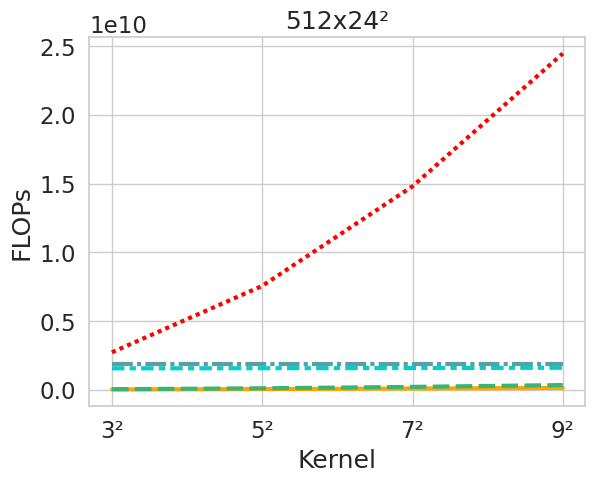

In [58]:
import seaborn as sns
from matplotlib import pyplot as plt

sns.set(font_scale=1.5, style='whitegrid')
line_width = 3
custom_palette = {
    'pooling': 'orange',
    'conv': 'red',
    'grouped conv': 'mediumseagreen',
    'local attn': 'darkturquoise',
    'global attn': 'cadetblue',
}
custom_linestyle = {
    'pooling': '',
    'conv': '',
    'grouped conv': (0, (5, 5)),
    'local attn': '',
    'global attn': '--',
}

for spatial_dim, g_df in results_df.groupby('spatial', sort=False):
    row_full_atn = g_df[g_df['operation'] == 'global attn']
    # g_df = g_df[g_df['operation'] != 'global attn']

    plt.figure()
    use_legend = True if spatial_dim.split('x')[0] == '320' else False
    ln_plot_kwargs = dict(x='kernel', hue='operation', data=g_df, linewidth=line_width, palette=custom_palette, style='operation', legend=use_legend)
    g = sns.lineplot(y='flops', **ln_plot_kwargs)
    if use_legend:
        g.legend_.set_title(None)
    plt.xlabel('Kernel')
    plt.ylabel('FLOPs')
    plt.title(spatial_dim)
    plt.savefig(f'flops_{spatial_dim.split('x')[0]}.pdf', dpi=300, bbox_inches='tight', pad_inches=0)

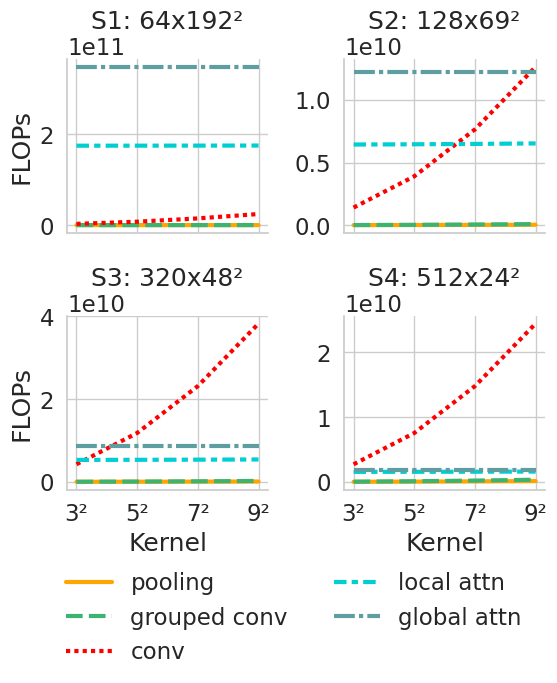

In [59]:
#df_selected = results_df[results_df['spatial'].str.startswith(('64', '320'))]

g = sns.FacetGrid(results_df, col='spatial', sharey=False, col_wrap=2)
g.map_dataframe(sns.lineplot, x='kernel', y='flops', hue='operation', style='operation', linewidth=line_width, palette=custom_palette)
g.set_axis_labels("Kernel", "FLOPs")
g.set_titles('{col_name}')
g.add_legend()

# Add enumeration to titles
for i, ax in enumerate(g.axes.flat, start=1):
    title = ax.get_title()
    ax.set_title(f"S{i}: {title}")

# Rebuild the legend with proper options
handles, labels = g.axes[0].get_legend_handles_labels()
g.fig.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.37, -0.17),
    ncol=2,
    frameon=False
)

g._legend.remove()  # remove the old one
g.tight_layout()
g.savefig(f'flops_total.pdf', dpi=300, bbox_inches='tight', pad_inches=0)

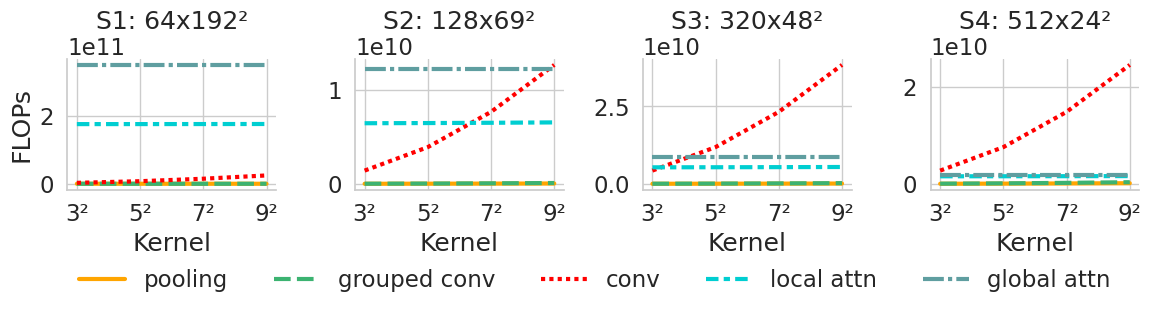

In [60]:
g = sns.FacetGrid(results_df, col='spatial', sharey=False)
g.map_dataframe(sns.lineplot, x='kernel', y='flops', hue='operation', style='operation', linewidth=line_width, palette=custom_palette)
g.set_axis_labels("Kernel", "FLOPs")
g.set_titles('{col_name}')
g.add_legend()

# Add enumeration to titles
for i, ax in enumerate(g.axes.flat, start=1):
    title = ax.get_title()
    ax.set_title(f"S{i}: {title}")

# Rebuild the legend with proper options
handles, labels = g.axes[0, 0].get_legend_handles_labels()
g.fig.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.425, -0.1),
    ncol=len(labels),
    frameon=False
)

g._legend.remove()  # remove the old one
g.tight_layout()
g.savefig(f'flops_total.pdf', dpi=300, bbox_inches='tight', pad_inches=0)

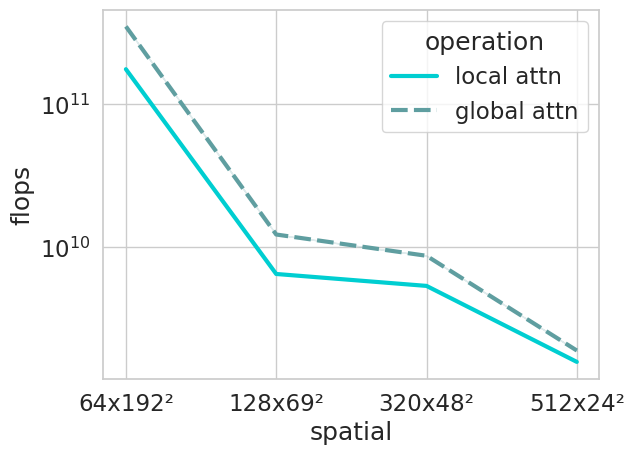

In [61]:
ax = sns.lineplot(results_df[results_df['operation'].str.endswith('attn')], x='spatial', y='flops', hue='operation', style='operation', linewidth=line_width, palette=custom_palette)
ax.set_yscale('log')

# Based on formulas

In [62]:
formula_df = pd.DataFrame(columns=['operation', 'kernel', 'spatial', 'flops'])
for K in [3, 5, 7, 9]:
    for C, D in [(64, 192), (128, 69), (320, 48), (512, 24)]:
        kernel_label = f'{K}²'
        spatial_label = f'{C}x{D}²'
        N = D ** 2

        pool_flops = N * K ** 2 * C + N * C ** 2
        formula_df.loc[len(formula_df)] = ['pooling', kernel_label, spatial_label, pool_flops]

        group_conv_flops = N * 2 * K ** 2 * C + N * C ** 2
        formula_df.loc[len(formula_df)] = ['grouped conv', kernel_label, spatial_label, group_conv_flops]

        conv_flops = N * 2 * K ** 2 * C ** 2 + N * C ** 2
        formula_df.loc[len(formula_df.index)] = ['conv', kernel_label, spatial_label, conv_flops]

        local_attn_flops = 5 * N * C ** 2 + N * K ** 2 * C + N + 2 * N * K**2
        formula_df.loc[len(formula_df.index)] = ['local attn', kernel_label, spatial_label, local_attn_flops]

        full_atn_flops = 5 * N * C ** 2 + N ** 2 * C + N + 2 * N ** 2
        formula_df.loc[len(formula_df.index)] = ['global attn', kernel_label, spatial_label, full_atn_flops]

print(formula_df)

       operation kernel  spatial        flops
0        pooling     3²  64x192²    172228608
1   grouped conv     3²  64x192²    193462272
2           conv     3²  64x192²   2868903936
3     local attn     3²  64x192²    776908800
4    global attn     3²  64x192²  90446008320
..           ...    ...      ...          ...
75       pooling     9²  512x24²    174882816
76  grouped conv     9²  512x24²    198770688
77          conv     9²  512x24²  24612175872
78    local attn     9²  512x24²    778956480
79   global attn     9²  512x24²    925508160

[80 rows x 4 columns]


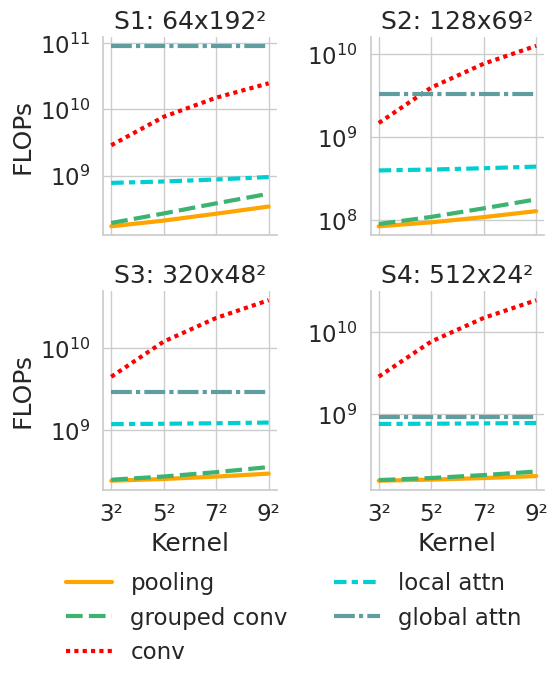

In [69]:
g = sns.FacetGrid(formula_df, col='spatial', sharey=False, col_wrap=2)
g.map_dataframe(sns.lineplot, x='kernel', y='flops', hue='operation', style='operation', linewidth=line_width, palette=custom_palette)
g.set(yscale='log')
g.set_axis_labels("Kernel", "FLOPs")
g.set_titles('{col_name}')
g.add_legend()

# Add enumeration to titles
for i, ax in enumerate(g.axes.flat, start=1):
    title = ax.get_title()
    ax.set_title(f"S{i}: {title}")

# Rebuild the legend with proper options
handles, labels = g.axes[0].get_legend_handles_labels()
g.fig.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.37, -0.17),
    ncol=2,
    frameon=False
)

g._legend.remove()  # remove the old one
g.tight_layout()
g.savefig(f'flops_total.pdf', dpi=300, bbox_inches='tight', pad_inches=0)

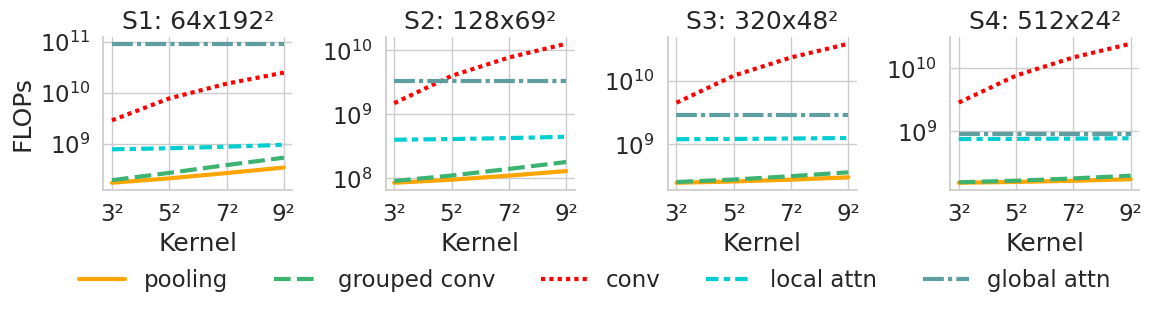

In [72]:
g = sns.FacetGrid(formula_df, col='spatial', sharey=False)
g.map_dataframe(sns.lineplot, x='kernel', y='flops', hue='operation', style='operation', linewidth=line_width, palette=custom_palette)
g.set(yscale='log')
g.set_axis_labels("Kernel", "FLOPs")
g.set_titles('{col_name}')
g.add_legend()

# Add enumeration to titles
for i, ax in enumerate(g.axes.flat, start=1):
    title = ax.get_title()
    ax.set_title(f"S{i}: {title}")

# Rebuild the legend with proper options
handles, labels = g.axes[0, 0].get_legend_handles_labels()
g.fig.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.425, -0.1),
    ncol=len(labels),
    frameon=False
)

g._legend.remove()  # remove the old one
g.tight_layout()
g.savefig(f'flops_total.pdf', dpi=300, bbox_inches='tight', pad_inches=0)

       operation kernel  spatial        flops
0        pooling     3²  64x192²    172228608
1   grouped conv     3²  64x192²    193462272
2           conv     3²  64x192²   2868903936
3     local attn     3²  64x192²    776908800
4    global attn     3²  64x192²  90446008320
..           ...    ...      ...          ...
75       pooling     9²  512x24²    174882816
76  grouped conv     9²  512x24²    198770688
77          conv     9²  512x24²  24612175872
78    local attn     9²  512x24²    778956480
79   global attn     9²  512x24²    925508160

[80 rows x 4 columns]


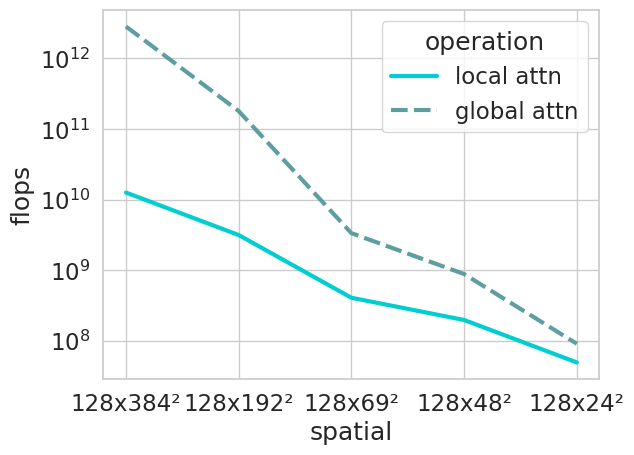

In [77]:
loc_df = pd.DataFrame(columns=['operation', 'kernel', 'spatial', 'flops'])
K = 5
C = 128
for D in [384, 192, 69, 48, 24]:
    kernel_label = f'{K}²'
    spatial_label = f'{C}x{D}²'
    N = D ** 2

    local_attn_flops = 5 * N * C ** 2 + N * K ** 2 * C + N + 2 * N * K ** 2
    loc_df.loc[len(loc_df.index)] = ['local attn', kernel_label, spatial_label, local_attn_flops]

    full_atn_flops = 5 * N * C ** 2 + N ** 2 * C + N + 2 * N ** 2
    loc_df.loc[len(loc_df.index)] = ['global attn', kernel_label, spatial_label, full_atn_flops]

print(formula_df)

ax = sns.lineplot(loc_df, x='spatial', y='flops', hue='operation', style='operation', linewidth=line_width,
                  palette=custom_palette)
ax.set_yscale('log')